## (0) Settings and Functions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize

from sklearn.feature_extraction.text import CountVectorizer

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

In [7]:
df = pd.read_csv("../../data/treated/tweet_emotions_ptbr_treated.csv")

df['BASE_TEXT'] = (
    df['BASE_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 7)


,texto,EMOTION,UNCLEAN_TEXT,BASE_TEXT,TEXT_NO_STOP,TEXT_LEMMA,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,que jubilo incalculavel ver todos meus querido...,jubilo incalculavel queridos prestaram ano pas...,que jubilo incalculavel ver todo meu querido q...,jubilo incalculavel querido prestar ano passad...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",sapontamentoi senhor arranca meu coracao qualq...,sapontamentoi senhor arranca coracao desaponta...,sapontamentoir senhor arrancar meu coracao qua...,sapontamentoir senhor arrancar coracao desapon...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,"A franquia continua ativa, com o desenvolvimen...",franquia continua ativa com desenvolvimento jo...,franquia continua ativa desenvolvimento jogo p...,franquia continuar ativo com desenvolvimento j...,franquia continuar ativo desenvolvimento jogo ...


In [8]:
def evaluate_on_test(pipe, X_train, y_train, X_test, y_test, le, model_name="model"):
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    metrics_df = pd.DataFrame({
        "Accuracy": [acc],
        "Precision (Macro)": [prec_macro],
        "Recall (Macro)": [rec_macro],
        "F1-score (Macro)": [f1_macro]
    })

    print("\n===== MÉTRICAS GLOBAIS =====")
    print(metrics_df.round(4))

    print("\n===== MÉTRICAS POR CLASSE =====")

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    # remover linhas agregadas se quiser só classes
    report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")

    # arredondar para 2 casas
    report_df = report_df.round(2)
    
    report_df.index = le.inverse_transform(report_df.index.astype(int))
    print(report_df)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Matriz de Confusão")
    plt.ylabel("Real")
    plt.xlabel("Predito")
    plt.show()

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)

        classes = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=classes)

        plt.figure(figsize=(12, 10))

        for i, class_label in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Classe {class_label} (AUC = {roc_auc:.2f})")

        # micro-average
        fpr_micro, tpr_micro, _ = roc_curve(
            y_test_bin.ravel(),
            y_score.ravel()
        )
        auc_micro = auc(fpr_micro, tpr_micro)

        plt.plot(
            fpr_micro,
            tpr_micro,
            linestyle="--",
            label=f"Micro-average (AUC = {auc_micro:.2f})"
        )

        plt.plot([0, 1], [0, 1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curva ROC Multiclasse")
        plt.legend()
        plt.show()
    else:
        print("Modelo não possui predict_proba. ROC não calculada.")

    model_file = f"../../data/model/TweetEmotionsPTBR_{model_name}.jolib"
    joblib.dump(pipe, model_file)

    print(f"\nModelo salvo em: {model_file}")

    metrics_df.to_csv(f"../../data/out/final/TweetEmotionsPTBR_{model_name}_global_metrics.csv", index=False)

## (1) Predict Final

In [9]:
X_text = df['BASE_TEXT']

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(8693,) (1863,) (1863,)



===== MÉTRICAS GLOBAIS =====
   Accuracy  Precision (Macro)  Recall (Macro)  F1-score (Macro)
0    0.9581              0.959          0.9583            0.9586

===== MÉTRICAS POR CLASSE =====
               precision  recall  f1-score  support
agressividade       0.92    0.93      0.93    119.0
alegria             0.94    0.93      0.94    120.0
amor                0.93    0.97      0.95    117.0
antecipacao         0.99    0.99      0.99    109.0
confianca           0.93    0.96      0.94    115.0
decepção            0.95    0.93      0.94    117.0
desprezo            1.00    0.98      0.99    120.0
intimidação         1.00    0.97      0.99    105.0
medo                0.99    0.98      0.99    118.0
nojo                0.96    0.97      0.96    118.0
otimismo            0.98    0.99      0.98    121.0
raiva               0.98    0.97      0.98    119.0
remorso             0.98    0.99      0.99    116.0
submissão           0.97    0.97      0.97    119.0
surpresa            0.95   

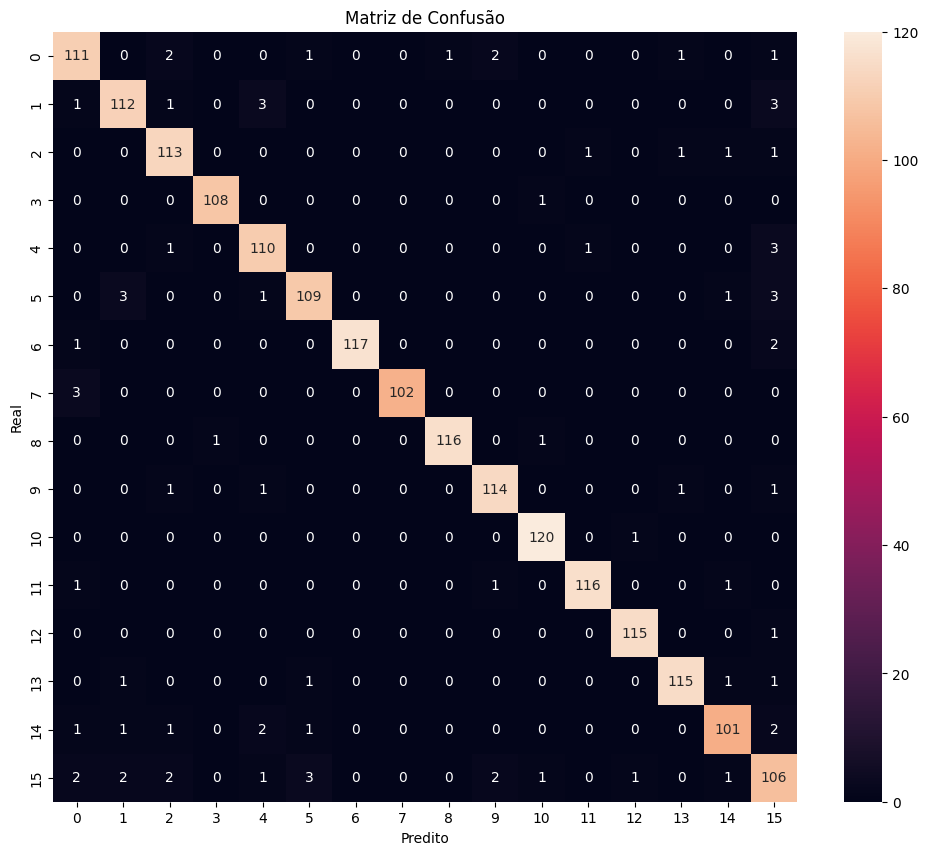

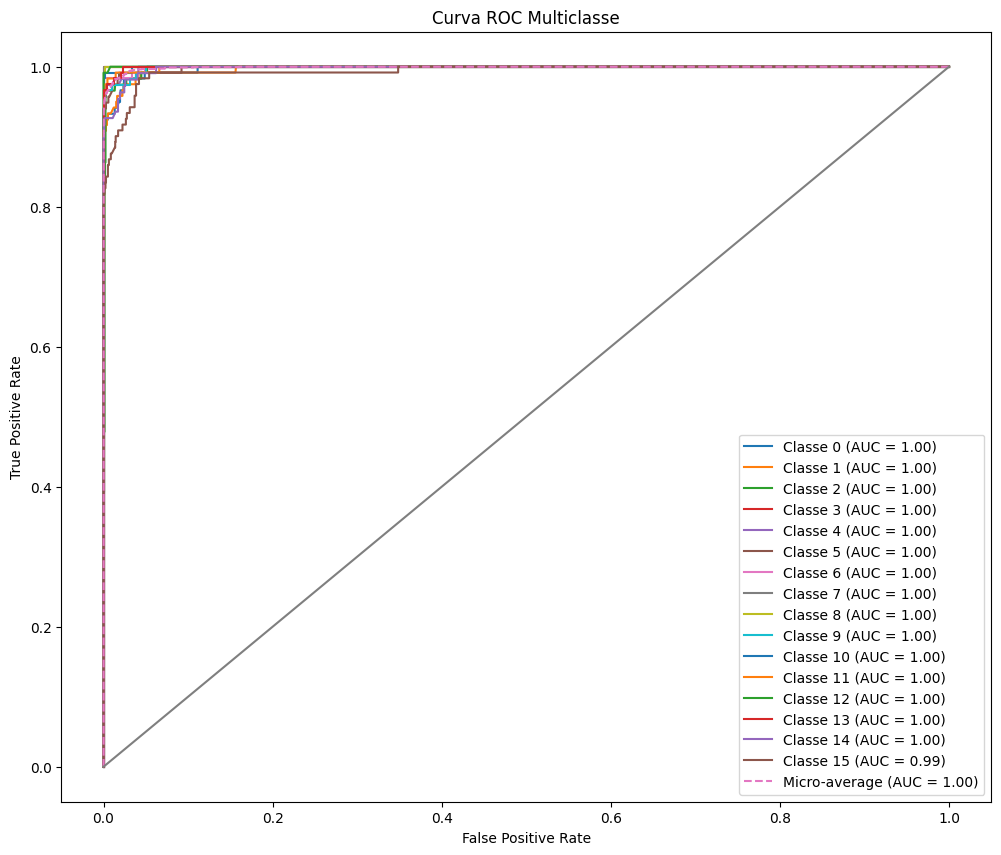


Modelo salvo em: ../../data/model/TweetEmotionsPTBR_XGBoost_BoW.jolib


In [10]:
model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

pipe = ImbPipeline([
    ("bow", CountVectorizer()),
    ("smote", SMOTE(random_state=42)),
    ("model", model)
])

evaluate_on_test(pipe, X_text_train, y_train, X_text_test, y_test, le, model_name="XGBoost_BoW")